In [1]:
import sklearn
import numpy as np
import pandas as pd

### Data exploration

- Check out data shape, size, structure, missing values, ...
- ACP to determine most important variables
- Visualisation to observe trends



Load a second dataset with reviews, match by appid (should be universal for steam)
Price tag: free, cheap, normal price, expensive, very expensive. + discount tag 
correlation between: price, reviews. genre and reviews, company/publisher and price + reviews 

recs based on: reviews, genres, general sentiment from the reviews (type of game, style of gameplay, Vibe) 


EDA:
best sellign games/genres/publishers. Signs of client satisfaction. 

In [2]:
games=pd.read_json("data/games.json").T.reset_index()
games.rename(columns={"index":"app_id"},inplace=True)


In [3]:
games.info
games.columns.tolist()
print(games['genres'].head(3))
print(games['tags'].head(3))
print(games['movies'].head(5))
games.isnull().sum()


0             []
1    [Adventure]
2       [Casual]
Name: genres, dtype: object
0                                                   []
1    {'Adventure': 27, 'Visual Novel': 19, 'Anime':...
2    {'Casual': 83, 'Card Game': 52, 'Solitaire': 4...
Name: tags, dtype: object
0    []
1    []
2    []
3    []
4    []
Name: movies, dtype: object


app_id                      0
name                        0
release_date                0
required_age                0
price                       0
dlc_count                   0
detailed_description        0
about_the_game              0
short_description           0
reviews                     0
header_image                0
website                     0
support_url                 0
support_email               0
windows                     0
mac                         0
linux                       0
metacritic_score            0
metacritic_url              0
achievements                0
recommendations             0
notes                       0
supported_languages         0
full_audio_languages        0
packages                    0
developers                  0
publishers                  0
categories                  0
genres                      0
screenshots                 0
movies                      0
user_score                  0
score_rank                  0
positive  

In [4]:
mask = (
    (games['short_description'] == '') &
    (games['genres'].apply(lambda x: x == [])) &
    (games['tags'].apply(lambda x: x == [] or x == {}))
)
mask.sum()

games_clean = games[~mask].reset_index(drop=True)

games_clean=games_clean.drop(columns=["support_url","support_email","metacritic_score","metacritic_url","achievements","recommendations","notes","movies","average_playtime_2weeks","median_playtime_2weeks","peak_ccu","discount","dlc_count"])

In [5]:
games_clean.head(5)

,app_id,name,release_date,required_age,price,detailed_description,about_the_game,short_description,reviews,header_image,...,genres,screenshots,user_score,score_rank,positive,negative,estimated_owners,average_playtime_forever,median_playtime_forever,tags
0,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0,5.24,"Springtime, April: when the cherry trees come ...","Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",,https://shared.akamai.steamstatic.com/store_it...,...,[Adventure],[https://shared.akamai.steamstatic.com/store_i...,0,,252,3,0 - 20000,8,8,"{'Adventure': 27, 'Visual Novel': 19, 'Anime':..."
1,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0,4.99,"Immerse yourself in the most beloved, mystical...","Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,,https://shared.akamai.steamstatic.com/store_it...,...,[Casual],[https://shared.akamai.steamstatic.com/store_i...,0,,21,3,0 - 20000,0,0,"{'Casual': 83, 'Card Game': 52, 'Solitaire': 4..."
2,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0,8.99,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...","synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",Yuha! I'll start the broadcast! Hakko's extrem...,,https://shared.akamai.steamstatic.com/store_it...,...,"[Casual, Indie, Simulation]",[https://shared.akamai.steamstatic.com/store_i...,0,,0,0,0 - 20000,0,0,[]
3,3631080,Maze Quest VR,"Apr 24, 2025",0,4.99,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,,https://shared.akamai.steamstatic.com/store_it...,...,"[Action, Early Access]",[https://shared.akamai.steamstatic.com/store_i...,0,,0,0,0 - 20000,0,0,[]
4,1654170,Agony VR,"Apr 5, 2023",0,13.99,ADD TO WISHLIST About the Game A JOURNEY THROU...,A JOURNEY THROUGH HELL! Explore the most terri...,Agony VR is a first-person survival horror gam...,,https://shared.akamai.steamstatic.com/store_it...,...,"[Action, Adventure]",[https://shared.akamai.steamstatic.com/store_i...,0,,0,0,0 - 20000,0,0,[]


TODO: 
- Filtrer les jeux complètement vides
- Regrouper windows, mac, linux → colonne os
- Créer la colonne price_range (free / cheap / moderate / expensive)
- Convertir estimated_owners de string "0 - 20000" vers quelque chose d'utilisable (moyenne ou borne haute)
- Créer une colonne total_reviews = positive + negative
- Créer une colonne positive_ratio = positive / total_reviews (attention division par zéro)

In [7]:
def get_os(row):
    os_list=[]
    if row["windows"]:
        os_list.append("windows")
    if row["linux"]:
        os_list.append("linux")
    if row["mac"]:
        os_list.append("mac")
    return os_list

games_clean["os"]=games_clean.apply(get_os, axis=1)
games_clean.drop(columns=["windows","mac","linux","estimated_owners"])

,app_id,name,release_date,required_age,price,detailed_description,about_the_game,short_description,reviews,header_image,...,genres,screenshots,user_score,score_rank,positive,negative,average_playtime_forever,median_playtime_forever,tags,os
0,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0,5.24,"Springtime, April: when the cherry trees come ...","Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",,https://shared.akamai.steamstatic.com/store_it...,...,[Adventure],[https://shared.akamai.steamstatic.com/store_i...,0,,252,3,8,8,"{'Adventure': 27, 'Visual Novel': 19, 'Anime':...",[windows]
1,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0,4.99,"Immerse yourself in the most beloved, mystical...","Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,,https://shared.akamai.steamstatic.com/store_it...,...,[Casual],[https://shared.akamai.steamstatic.com/store_i...,0,,21,3,0,0,"{'Casual': 83, 'Card Game': 52, 'Solitaire': 4...","[windows, mac]"
2,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0,8.99,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...","synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",Yuha! I'll start the broadcast! Hakko's extrem...,,https://shared.akamai.steamstatic.com/store_it...,...,"[Casual, Indie, Simulation]",[https://shared.akamai.steamstatic.com/store_i...,0,,0,0,0,0,[],[windows]
3,3631080,Maze Quest VR,"Apr 24, 2025",0,4.99,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,,https://shared.akamai.steamstatic.com/store_it...,...,"[Action, Early Access]",[https://shared.akamai.steamstatic.com/store_i...,0,,0,0,0,0,[],[windows]
4,1654170,Agony VR,"Apr 5, 2023",0,13.99,ADD TO WISHLIST About the Game A JOURNEY THROU...,A JOURNEY THROUGH HELL! Explore the most terri...,Agony VR is a first-person survival horror gam...,,https://shared.akamai.steamstatic.com/store_it...,...,"[Action, Adventure]",[https://shared.akamai.steamstatic.com/store_i...,0,,0,0,0,0,[],[windows]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114336,4152910,完美传奇,"Jan 4, 2026",0,0.0,《完美传奇》游戏介绍 🔥【完美传奇——专属大陆的奇幻史诗！】🔥 🌍耗时两年匠心打造，诚意之作...,《完美传奇》游戏介绍 🔥【完美传奇——专属大陆的奇幻史诗！】🔥 🌍耗时两年匠心打造，诚意之作...,欢迎来到《完美传奇》！ 🌍专属大陆×自由探索，六道轮回剧情×百变BUFF搭配，一刀爆神装、机...,,https://shared.akamai.steamstatic.com/store_it...,...,"[Action, Adventure, Massively Multiplayer, RPG...",[https://shared.akamai.steamstatic.com/store_i...,0,,0,0,0,0,[],[windows]
114337,4042800,Poker Fate - ACG Texas Hold'em,"Jan 3, 2026",0,0.0,Poker Fate – Choose your poker partner and ent...,Poker Fate – Choose your poker partner and ent...,Poker Fate is an anime-style Texas Hold'em gam...,,https://shared.akamai.steamstatic.com/store_it...,...,"[Casual, Strategy, Free To Play]",[https://shared.akamai.steamstatic.com/store_i...,0,,0,0,0,0,[],[windows]
114338,3522550,Adira Nusantara,"Jan 3, 2026",0,7.99,(Gif character) Adira Nusantara is a side-scro...,(Gif character) Adira Nusantara is a side-scro...,"Master authentic Silat combat as Adira, a fier...",,https://shared.akamai.steamstatic.com/store_it...,...,"[Action, Adventure, Casual, Early Access]",[https://shared.akamai.steamstatic.com/store_i...,0,,0,0,0,0,[],[windows]
114339,3680350,A Lenda de Niterói,"Jan 4, 2026",0,2.09,"Step into the role of Arariboia, a legendary I...","Step into the role of Arariboia, a legendary I...",Embark on Arariboia’s journey during the 16th-...,,https://shared.akamai.steamstatic.com/store_it...,...,"[Action, Adventure, Casual, Indie]",[https://shared.akamai.steamstatic.com/store_i...,0,,0,0,0,0,[],[windows]


In [8]:
games_clean["total_reviews"]=games_clean["positive"]+games_clean["negative"]
games_clean["positive_ratio"]=games_clean["positive"] / games_clean["total_reviews"].replace(0, np.nan)
games_clean.head(5)

,app_id,name,release_date,required_age,price,detailed_description,about_the_game,short_description,reviews,header_image,...,score_rank,positive,negative,estimated_owners,average_playtime_forever,median_playtime_forever,tags,os,total_reviews,positive_ratio
0,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0,5.24,"Springtime, April: when the cherry trees come ...","Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",,https://shared.akamai.steamstatic.com/store_it...,...,,252,3,0 - 20000,8,8,"{'Adventure': 27, 'Visual Novel': 19, 'Anime':...",[windows],255,0.988235
1,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0,4.99,"Immerse yourself in the most beloved, mystical...","Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,,https://shared.akamai.steamstatic.com/store_it...,...,,21,3,0 - 20000,0,0,"{'Casual': 83, 'Card Game': 52, 'Solitaire': 4...","[windows, mac]",24,0.875
2,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0,8.99,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...","synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",Yuha! I'll start the broadcast! Hakko's extrem...,,https://shared.akamai.steamstatic.com/store_it...,...,,0,0,0 - 20000,0,0,[],[windows],0,NaN
3,3631080,Maze Quest VR,"Apr 24, 2025",0,4.99,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,,https://shared.akamai.steamstatic.com/store_it...,...,,0,0,0 - 20000,0,0,[],[windows],0,NaN
4,1654170,Agony VR,"Apr 5, 2023",0,13.99,ADD TO WISHLIST About the Game A JOURNEY THROU...,A JOURNEY THROUGH HELL! Explore the most terri...,Agony VR is a first-person survival horror gam...,,https://shared.akamai.steamstatic.com/store_it...,...,,0,0,0 - 20000,0,0,[],[windows],0,NaN


In [9]:
games_clean.columns.tolist()

['app_id',
 'name',
 'release_date',
 'required_age',
 'price',
 'detailed_description',
 'about_the_game',
 'short_description',
 'reviews',
 'header_image',
 'website',
 'windows',
 'mac',
 'linux',
 'supported_languages',
 'full_audio_languages',
 'packages',
 'developers',
 'publishers',
 'categories',
 'genres',
 'screenshots',
 'user_score',
 'score_rank',
 'positive',
 'negative',
 'estimated_owners',
 'average_playtime_forever',
 'median_playtime_forever',
 'tags',
 'os',
 'total_reviews',
 'positive_ratio']

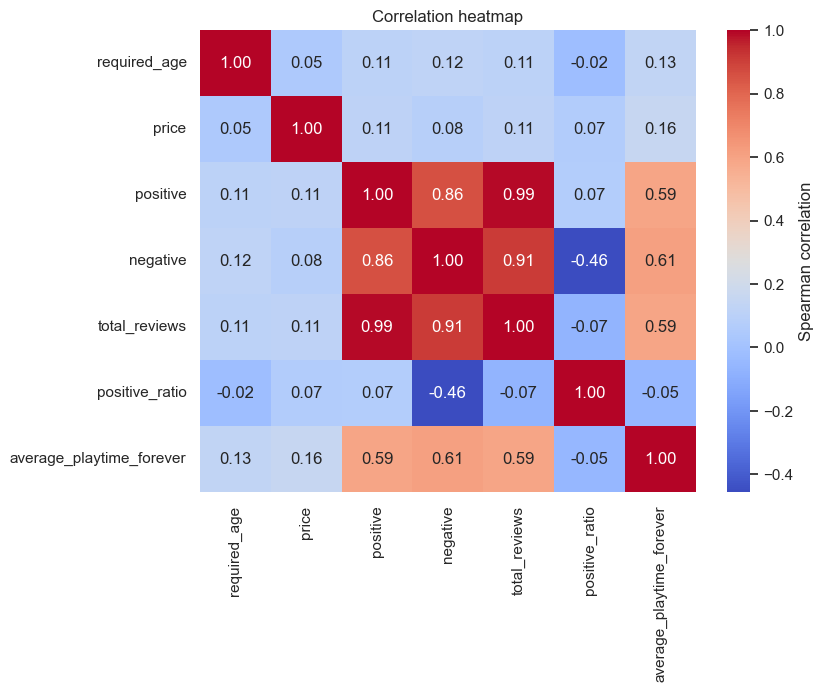

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
columns_of_interest=['required_age','price','positive','negative','total_reviews','positive_ratio','average_playtime_forever']

correlation_matrix=games_clean[columns_of_interest].corr(method="spearman")

sns.set_theme(style="white")
plt.figure(figsize=(8,6))
heatmap=sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"label": "Spearman correlation"})
heatmap.set_title("Correlation heatmap")
plt.show()

Strong correlation:
- reviews (positive/negative) and the average playtime: logical, games with higher playtimes will have a bigger amount of reviews. 
- 
Weak correlation:
- positive ratio with negative reviews: logical.

no other apparent significant correlations
- price doesnt necessarily signify a game will be played more or reviewed more

jeux gratuits: 17938


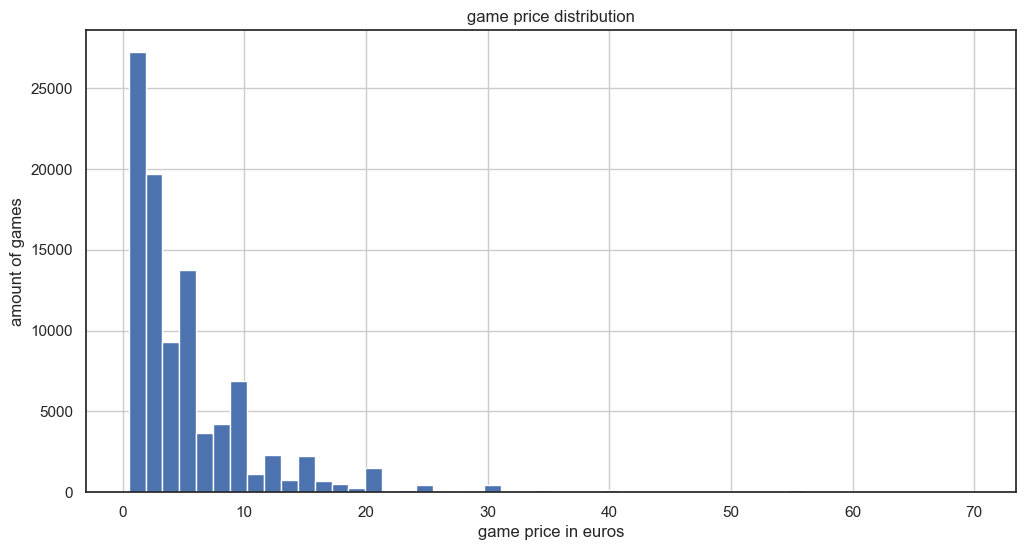

In [34]:
games_clean["price"].describe()
print("jeux gratuits:",(games_clean["price"] == 0).sum())
plt.figure(figsize=(12, 6))
games_clean[(games_clean["price"] <= 70)&(games_clean["price"]>0)]["price"].hist(bins=50)
plt.title("game price distribution")
plt.xlabel("game price in euros")
plt.ylabel("amount of games")
plt.show()

genres
Indie                    80630
Casual                   50210
Action                   46220
Adventure                45141
Simulation               24114
Strategy                 22400
RPG                      20972
Free To Play             12172
Early Access             11091
Sports                    4882
Racing                    4079
Massively Multiplayer     2527
Utilities                 1077
Design & Illustration      580
Animation & Modeling       477
Education                  461
Violent                    414
Video Production           339
Game Development           320
Gore                       257
Audio Production           225
Software Training          219
Photo Editing              180
Web Publishing             112
Nudity                      94
Sexual Content              88
Accounting                  30
Movie                        2
Documentary                  1
Episodic                     1
Name: count, dtype: int64
702 jeux supprimés
(113639, 33)


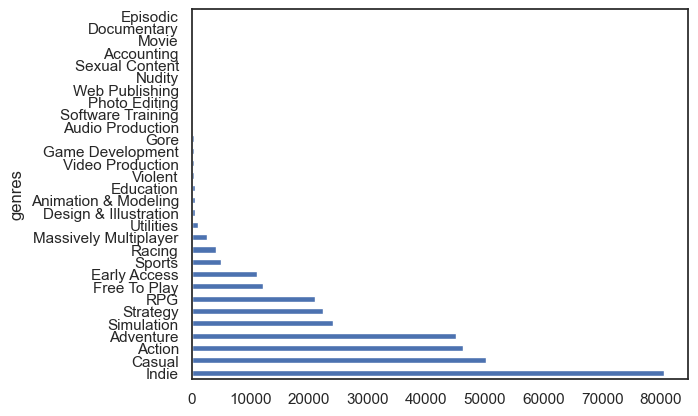

In [43]:
games_clean["genres"].explode().value_counts().head(30).plot(kind='barh')
print(games_clean["genres"].explode().value_counts().head(30))
non_games=["Utilities","Design & Illustration","Animation & Modeling","Audio Production","Web Publishing","Software Training","Accounting"]

mask = games_clean['genres'].apply(lambda x: all(genre in non_games for genre in x))
games_clean=games_clean[~mask]
print(mask.sum(), "jeux supprimés")
print(games_clean.shape)

tags
Singleplayer        50260
Indie               48478
Action              36774
Casual              36492
Adventure           35166
2D                  26734
3D                  17970
Simulation          17858
Strategy            17817
Puzzle              16343
Atmospheric         16239
RPG                 15716
Colorful            14243
Pixel Graphics      13851
Story Rich          13315
Exploration         13219
Cute                12636
First-Person        12284
Arcade              11489
Fantasy             11479
Early Access        10225
Multiplayer         10129
Funny                9842
Horror               9659
Action-Adventure     9600
Retro                9252
Shooter              9202
Relaxing             9094
Family Friendly      8886
Platformer           8789
Name: count, dtype: int64


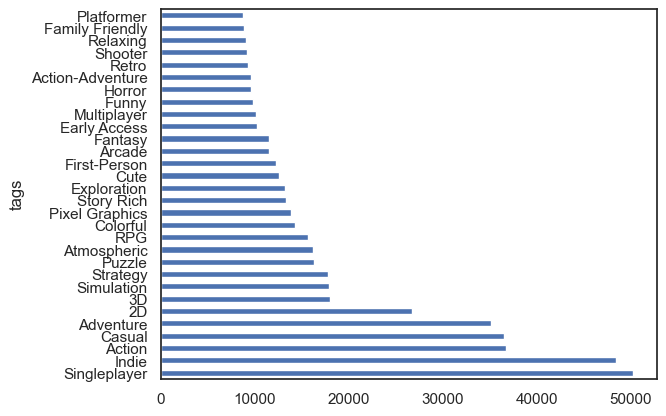

In [49]:
games_clean["tags"].apply(lambda x: list(x.keys()) if isinstance(x, dict) else []).explode().value_counts().head(30).plot(kind='barh')
print(games_clean["tags"].apply(lambda x: list(x.keys()) if isinstance(x, dict) else []).explode().value_counts().head(30))


Les tags sont beaucoup plus granulaires 2D, Atmospheric, Pixel Graphics, Story Rich n'existent pas dans les genres officiels
Singleplayer est le tag dominant ça dit quelque chose sur la nature de Steam (majorité de jeux solo)


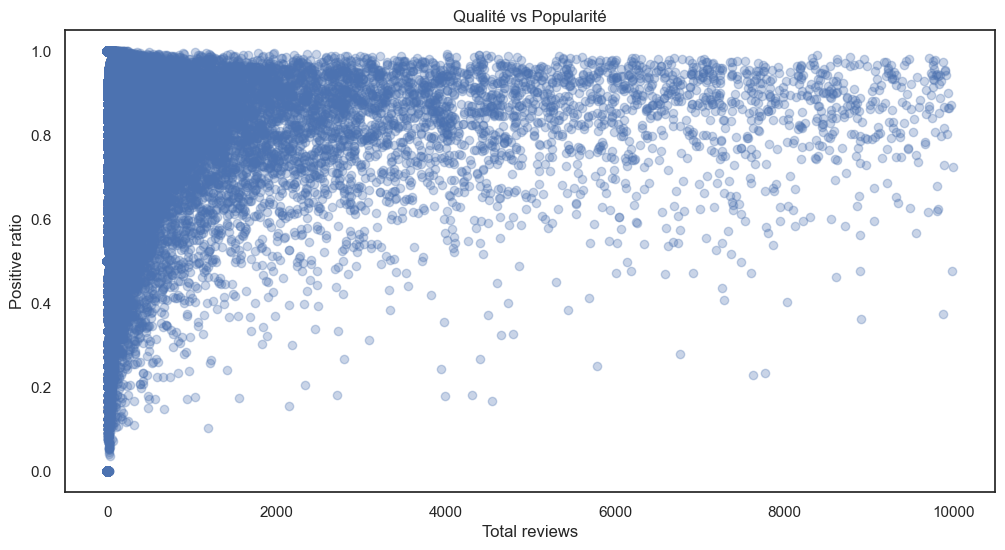

In [54]:
plt.figure(figsize=(12, 6))
filtered = games_clean[games_clean["total_reviews"] < 10000]
plt.scatter(x=filtered["total_reviews"], y=filtered["positive_ratio"], alpha=0.3)
plt.xlabel("Total reviews")
plt.ylabel("Positive ratio")
plt.title("Qualité vs Popularité")
plt.show()

Énorme varianceà gauche, jeux à 100% positif et d'autres à 0 pourcent. à droite bcp de reviews, le nuage se dessert vers le haut donc probablement avec des reviews plus positifs. Un jeu avec 5 reviews à 100% n'est pas forcément meilleur qu'un jeu avec 1000 reviews à 85%

## REVIEWS DATASET

In [67]:
reviews=pd.read_csv("data/reviews.csv")


In [71]:
reviews.info
top_reviews=reviews.groupby("app_id").apply(
    lambda x: " ".join(
    x.sort_values(by='review_votes', ascending=False)
    .head(5)['review_text']
    .fillna(""))
)
top_reviews = top_reviews.reset_index()
top_reviews.columns=['app_id','top_reviews_text']

In [72]:
top_reviews.head(10)

,app_id,top_reviews_text
0,10,"Was good... Now... Now it's full of hackers, n..."
1,20,When I got this for Christmas in 1999 along wi...
2,30,"Even though its old, its better than Call of D..."
3,40,Buy this game and join the community of one I ...
4,50,same as half life but u are a terrorist in the...
5,60,there's 1 map and you can throw discs 10/10 pr...
6,70,"Pros: -I got to be a soldier, a scientist, a s..."
7,80,Still better than CoD : Ghosts. its ok...not b...
8,130,The cupcake version of Half-Life. Play as Barn...
9,220,Play and understand why we need Half-Life 3. I...


In [73]:
print("Jeux dans games_clean:", games_clean['app_id'].nunique())
print("Jeux dans top_reviews:", top_reviews['app_id'].nunique())
print("Overlap:", games_clean['app_id'].isin(top_reviews['app_id']).sum())

Jeux dans games_clean: 113639
Jeux dans top_reviews: 9972
Overlap: 8674


In [82]:
games_final=games_clean.merge(top_reviews, how='left', on='app_id')
games_final.head(5)
games_final['top_reviews_text'] = games_final['top_reviews_text'].fillna("")
games_final['tags_text']=games_final['tags'].apply(lambda x: " ".join(x.keys()) if isinstance(x, dict) else "")
games_final['combined_text'] = games_final['short_description'] + " " + games_final['top_reviews_text'] + " " + games_final['tags_text']

games_final.head(10)

,app_id,name,release_date,required_age,price,detailed_description,about_the_game,short_description,reviews,header_image,...,estimated_owners,average_playtime_forever,median_playtime_forever,tags,os,total_reviews,positive_ratio,top_reviews_text,tags_text,combined_text
0,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0,5.24,"Springtime, April: when the cherry trees come ...","Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",,https://shared.akamai.steamstatic.com/store_it...,...,0 - 20000,8,8,"{'Adventure': 27, 'Visual Novel': 19, 'Anime':...",[windows],255,0.988235,,Adventure Visual Novel Anime Cute,"Spring has come, and our protagonist, Yukinari..."
1,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0,4.99,"Immerse yourself in the most beloved, mystical...","Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,,https://shared.akamai.steamstatic.com/store_it...,...,0 - 20000,0,0,"{'Casual': 83, 'Card Game': 52, 'Solitaire': 4...","[windows, mac]",24,0.875,,Casual Card Game Solitaire Puzzle Hidden Objec...,Discover an entrancing and spectacular world! ...
2,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0,8.99,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...","synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",Yuha! I'll start the broadcast! Hakko's extrem...,,https://shared.akamai.steamstatic.com/store_it...,...,0 - 20000,0,0,[],[windows],0,NaN,,,Yuha! I'll start the broadcast! Hakko's extrem...
3,3631080,Maze Quest VR,"Apr 24, 2025",0,4.99,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,,https://shared.akamai.steamstatic.com/store_it...,...,0 - 20000,0,0,[],[windows],0,NaN,,,Its not just a Maze; its a Quest! Enter the ca...
4,1654170,Agony VR,"Apr 5, 2023",0,13.99,ADD TO WISHLIST About the Game A JOURNEY THROU...,A JOURNEY THROUGH HELL! Explore the most terri...,Agony VR is a first-person survival horror gam...,,https://shared.akamai.steamstatic.com/store_it...,...,0 - 20000,0,0,[],[windows],0,NaN,,,Agony VR is a first-person survival horror gam...
5,1934300,Armored Brigade II,"Apr 8, 2025",0,35.99,Building on the success of its acclaimed prede...,Building on the success of its acclaimed prede...,Armored Brigade II revolutionizes real-time ta...,,https://shared.akamai.steamstatic.com/store_it...,...,0 - 20000,675,1253,"{'Simulation': 193, 'Strategy': 186, 'RTS': 16...",[windows],130,0.9,,Simulation Strategy RTS Wargame Grand Strategy...,Armored Brigade II revolutionizes real-time ta...
6,700340,Galacatraz: Eject Equip Escape,"Feb 1, 2018",0,0.99,"Years ago, Ricardo Luger was in the wrong plac...","Years ago, Ricardo Luger was in the wrong plac...","Escape Galacatraz, the universe's most secure ...",,https://shared.akamai.steamstatic.com/store_it...,...,0 - 20000,0,0,[],[windows],0,NaN,,,"Escape Galacatraz, the universe's most secure ..."
7,1157670,Hepta Beats,"May 7, 2021",0,0.99,Hepta Beats is a 2D side-view platformer game ...,Hepta Beats is a 2D side-view platformer game ...,Hepta Beats is a 2D side-view platformer game ...,,https://shared.akamai.steamstatic.com/store_it...,...,0 - 20000,0,0,"{'Precision Platformer': 52, 'Rhythm': 45, 'Mu...",[windows],32,0.875,,Precision Platformer Rhythm Music Difficult Ab...,Hepta Beats is a 2D side-view platformer game ...
8,1540330,MUMBA IV: Egypt Jewels,"Dec 13, 2021",0,0.59,WARRNING Don't show Your mom this game. You kn...,WARRNING Don't show Your mom this game. You kn...,Your task in MUMBA IV is to destroy coloured j...,,https://shared.akamai.steamstatic.com/store_it...,...,0 - 20000,0,0,"{'Casual': 64, 'Action': 51, 'Strategy': 42, '...","[windows, linux, mac]",25,0.76,,Casual Action Strategy Puzzle Match 3 Singlepl...,Your task in MUMBA IV is to destroy coloured j...
9,1108640,OMNIMUS,"Sep 25, 2019",0,0.99,Omnimus is an interactive visual novel in an u...,Omni

## EMEDDINGS

In [83]:
!pip install sentence-transformers

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.9/612.9 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 51.4 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 38.2 MB/s eta 0:00:00
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
Using cached markdown_it_py-4.0.0-py3-none-any.whl (87 kB)
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [85]:
from sentence_transformers import SentenceTransformer
model= SentenceTransformer('all-MiniLM-L6-v2')

(games_final['combined_text'] == "").sum()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


np.int64(0)

In [87]:
embeddings = model.encode(games_final['combined_text'].tolist(), show_progress_bar=True, batch_size=64)
np.save("data/embeddings.npy",embeddings)

Batches:   0%|          | 0/1776 [00:00<?, ?it/s]

In [89]:
print(embeddings.shape)
np.save("data/embeddings.npy", embeddings)


(113639, 384)


## recommendation system
- find index of game from name
- compute similarity
- sort and return top N results
- give back names from games_final

In [95]:
from sklearn.metrics.pairwise import cosine_similarity
def get_similar_games(game_name, n=10):
    game_idx=games_final.index[games_final['name'] == game_name][0]
    similarities=cosine_similarity([embeddings[game_idx]],embeddings)
    top_n_games=np.argsort(similarities[0])[::-1]
    return games_final['name'].iloc[top_n_games[1:n+1]]
    
game_idx = games_final.index[games_final['name'] == 'Counter-Strike'][0]
similarities = cosine_similarity([embeddings[game_idx]], embeddings)
top_indices = np.argsort(similarities[0])[::-1][1:11]
print(similarities[0][top_indices])




[0.68029195 0.6702334  0.6691165  0.6660125  0.65756166 0.65358603
 0.65209454 0.6479468  0.6473849  0.647205  ]


TypeError: print() got an unexpected keyword argument 'games_filtered'

In [99]:
print(games_final[games_final['total_reviews'] >= 10].shape)
games_final = games_final[games_final['total_reviews'] >= 10].reset_index(drop=True)
embeddings = model.encode(games_final['combined_text'].tolist(), show_progress_bar=True, batch_size=64)
np.save("data/embeddings.npy",embeddings)

(56265, 36)


Batches:   0%|          | 0/880 [00:00<?, ?it/s]

In [106]:
print(embeddings.shape)
np.save("data/embeddings.npy", embeddings)





(56265, 384)


41216    Counter-Strike: Condition Zero
43015    Dead Island Definitive Edition
27675                         Contagion
29058                        Noob Squad
6182                      Counter Spell
3629                         SPACE HUNT
33738                             BRINK
39558                 Elite vs. Freedom
5829             Infestation: The New Z
44802            Counter-Strike: Source
Name: name, dtype: object

In [107]:
!pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.2 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [120]:
from rapidfuzz import process, fuzz
from sklearn.metrics.pairwise import cosine_similarity

def get_similar_games(game_name, n=10):
    normalized_input = game_name.lower().replace("-", " ")
    normalized_names = games_final['name'].str.lower().str.replace("-", " ")
    
    best_match_idx = process.extractOne(
        normalized_input, 
        normalized_names,
        scorer=fuzz.token_sort_ratio
    )[2]
    
    matched_name = games_final['name'].iloc[best_match_idx]
    print(f"Jeu trouvé : {matched_name}")
    
    game_idx = best_match_idx
    similarities = cosine_similarity([embeddings[game_idx]], embeddings)
    top_n_games = np.argsort(similarities[0])[::-1]
    return games_final['name'].iloc[top_n_games[1:n+1]]

get_similar_games("counter srike")


Jeu trouvé : Counter-Strike


42506                                Last Mortem
47000    Call of Duty®: Modern Warfare® 2 (2009)
10267                         Kick Ass Commandos
48047                     Supreme Ruler Ultimate
52120                        Mafia Gangster City
29824                                        ACT
6853                              Under Pressure
34346    Call of Duty®: Modern Warfare® 3 (2011)
47358                             Neighbor Fight
687                                  Instability
Name: name, dtype: object